In [13]:
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy import units as u
import glob

# 1. 直接用 Pandas 讀取兩個 20 萬行的 CSV 檔案
df_my = sorted(glob.glob('../data/catalog/ps1/merged/*.csv'))
df_strm = sorted(glob.glob('../data/catalog/ps1/redshift_STRM/*.csv'))


In [14]:
for i in range(len(df_my)):
    df_a = pd.read_csv(df_my[i])
    df_b = pd.read_csv(df_strm[i])
    # 2. 將 RA/Dec 轉換為 Astropy 的 SkyCoord 物件
    #（假設欄位名稱為 'ra' 和 'dec'，單位是度 degree）
    cat_a = SkyCoord(ra=df_a['raMean'].values * u.deg, dec=df_a['decMean'].values * u.deg)
    cat_b = SkyCoord(ra=df_b['raMean'].values * u.deg, dec=df_b['decMean'].values * u.deg)
    # 3. 進行交叉比對（幫 cat_a 中的每一個天體，找出 cat_b 中最靠近鄰居）
    idx, d2d, _ = cat_a.match_to_catalog_sky(cat_b)

    # 4. 設定容許的極大匹配距離（例如 2 角秒）
    max_sep = 5.0 * u.arcsec
    is_match = d2d < max_sep
    # 5. 篩選並合併比對成功的資料
    results = df_a[is_match].copy()
    results['z_phot0'] = df_b.iloc[idx[is_match]]['z_phot0'].values
    results['z_photErr'] = df_b.iloc[idx[is_match]]['z_photErr'].values

    # 6. 儲存結果
    results.to_csv('../data/catalog/ps1/matched' +df_my[i].split('../data/catalog/ps1/merged')[1] , index=False)
    print(f"比對完成！共找到 {len(results)} 個匹配天體。")

比對完成！共找到 2873 個匹配天體。
比對完成！共找到 4343 個匹配天體。
比對完成！共找到 4441 個匹配天體。
比對完成！共找到 2346 個匹配天體。
比對完成！共找到 7868 個匹配天體。
比對完成！共找到 3619 個匹配天體。
比對完成！共找到 8056 個匹配天體。
比對完成！共找到 19724 個匹配天體。
比對完成！共找到 6880 個匹配天體。
比對完成！共找到 3903 個匹配天體。
比對完成！共找到 6474 個匹配天體。
比對完成！共找到 3958 個匹配天體。
比對完成！共找到 4677 個匹配天體。
比對完成！共找到 2378 個匹配天體。
比對完成！共找到 3833 個匹配天體。
比對完成！共找到 3969 個匹配天體。
比對完成！共找到 13923 個匹配天體。
比對完成！共找到 7561 個匹配天體。
比對完成！共找到 5116 個匹配天體。
比對完成！共找到 6737 個匹配天體。
比對完成！共找到 8667 個匹配天體。
比對完成！共找到 20705 個匹配天體。
比對完成！共找到 5269 個匹配天體。
比對完成！共找到 3254 個匹配天體。
比對完成！共找到 8611 個匹配天體。
比對完成！共找到 3518 個匹配天體。
比對完成！共找到 2540 個匹配天體。
比對完成！共找到 4192 個匹配天體。
比對完成！共找到 2470 個匹配天體。
比對完成！共找到 3725 個匹配天體。
比對完成！共找到 4004 個匹配天體。
比對完成！共找到 3816 個匹配天體。
比對完成！共找到 3618 個匹配天體。
比對完成！共找到 4642 個匹配天體。
比對完成！共找到 11413 個匹配天體。
比對完成！共找到 7974 個匹配天體。
比對完成！共找到 4320 個匹配天體。


KeyboardInterrupt: 

In [20]:
len(glob.glob('../data/catalog/ps1/matched/*.csv'))

492

In [3]:
df_local[0]

'../data/catalog/ps1/redshift_xgb/origin/t000.4369+11.1667.csv'

,objID,z_phot,z_phot_err,odds,D_L_Mpc,Absolute_Mag_r,Calculated_Flux
0,121400004368570507,0.101624,0.033827,0.671430,439.414475,-20.224555,0.000231
1,121400004474287812,0.451645,0.080328,0.412280,1781.558628,-21.027385,0.000029
2,121410004217311383,0.485154,0.110582,0.312986,1896.311032,-21.130401,0.000029
3,121410004495586704,0.411067,0.088980,0.365745,1639.479061,-20.911751,0.000031
4,121410004532792954,0.462046,0.050700,0.613023,1817.426334,-21.203413,0.000033
...,...,...,...,...,...,...,...
3025,121410012717419633,0.413091,0.054862,0.560311,1646.648851,-21.200301,0.000040
3026,121880011641484726,0.432519,0.080556,0.406302,1715.018620,-21.147172,0.000036
3027,120920011684187430,0.191111,0.070415,0.388172,807.926871,-20.320444,0.000075
3028,120460006997887388,0.216944,0.031369,0.755506,911.051380,-21.397019,0.000158


In [5]:
import pandas as pd
from astropy.table import Table
import astropy.units as u
from astroquery.xmatch import XMatch
import glob

# 1. 讀取您的 20 萬行本地 CSV 並轉換為 Astropy Table
df_local = glob.glob('../data/catalog/ps1/redshift/origin/*.csv')

i = 0  # 選擇要比對的 CSV 檔案索引
df_a = pd.read_csv(df_local[i])
local_table = Table.from_pandas(df_a)

# 2. 設定匹配參數（以 SDSS DR12 為例）
# 如果要使用其他版本的 SDSS，請替換 cat2 的 VizieR ID
sdss_dr12_id = 'vizier:V/147/sdss12' 

print("正在與 SDSS 進行雲端交叉比對...")

# 3. 執行跨目錄比對（設定容許距離為 2 角秒）
matched_table = XMatch.query(
    cat1=local_table,
    cat2=sdss_dr12_id,
    max_distance=0.2 * u.arcsec,
    colRA1='raMean',      # 您本地 CSV 的 RA 欄位名稱
    colDec1='decMean'     # 您本地 CSV 的 Dec 欄位名稱
)

# 4. 將結果轉回 Pandas DataFrame 並儲存
df_results = matched_table.to_pandas()
df_results.to_csv('../data/catalog/ps1/matched/sdss' +df_local[0].split('../data/catalog/ps1/redshift/origin')[1] , index=False)

print(f"比對完成！共找到 {len(df_results)} 個 SDSS 匹配天體。")


正在與 SDSS 進行雲端交叉比對...
比對完成！共找到 2814 個 SDSS 匹配天體。


In [11]:
df = pd.read_csv('../data/catalog/ps1/matched/sdss' +df_local[0].split('../data/catalog/ps1/redshift/origin')[1])
df_b = pd.read_csv('../data/catalog/ps1/redshift_xgb/origin/' +df_local[0].split('../data/catalog/ps1/redshift/origin')[1])

In [10]:
df_b

,objID,z_phot,z_phot_err,odds,D_L_Mpc,Absolute_Mag_r,Calculated_Flux
0,121400004368570507,0.101624,0.033827,0.671430,439.414475,-20.224555,0.000231
1,121400004474287812,0.451645,0.080328,0.412280,1781.558628,-21.027385,0.000029
2,121410004217311383,0.485154,0.110582,0.312986,1896.311032,-21.130401,0.000029
3,121410004495586704,0.411067,0.088980,0.365745,1639.479061,-20.911751,0.000031
4,121410004532792954,0.462046,0.050700,0.613023,1817.426334,-21.203413,0.000033
...,...,...,...,...,...,...,...
3025,121410012717419633,0.413091,0.054862,0.560311,1646.648851,-21.200301,0.000040
3026,121880011641484726,0.432519,0.080556,0.406302,1715.018620,-21.147172,0.000036
3027,120920011684187430,0.191111,0.070415,0.388172,807.926871,-20.320444,0.000075
3028,120460006997887388,0.216944,0.031369,0.755506,911.051380,-21.397019,0.000158


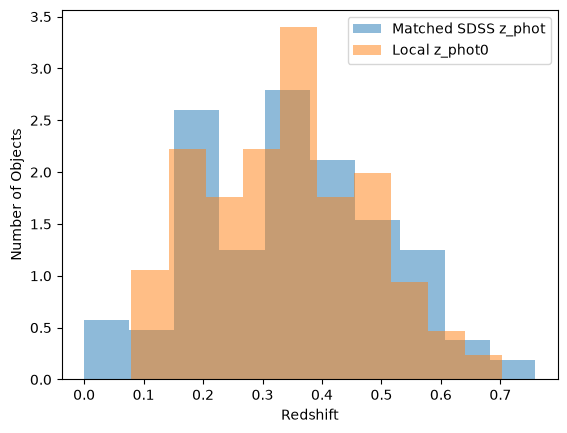

In [20]:
import matplotlib.pyplot as plt
plt.hist(df['zsp'], bins=10, alpha=0.5, label='Matched SDSS z_phot', density=True)
plt.hist(df_b['z_phot'][df_b['objID'].isin(df['objID'][df['zsp'].notnull()])], bins=10, alpha=0.5, label='Local z_phot0', density=True)
plt.xlabel('Redshift')
plt.ylabel('Number of Objects')
plt.legend()
plt.show()

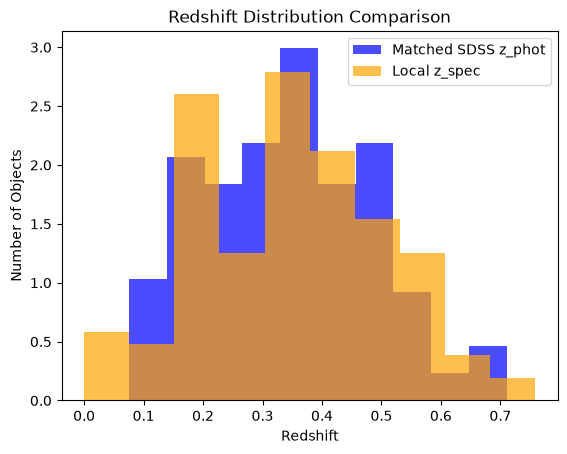

In [25]:
import matplotlib.pyplot as plt
plt.hist(df['z_phot'][df['zsp'].notnull()], bins=10, alpha=0.7, color='blue', label='Matched SDSS z_phot', density=True)
plt.hist(df['zsp'], bins=10, alpha=0.7, color='orange', label='Local z_spec', density=True)
plt.xlabel('Redshift')
plt.ylabel('Number of Objects')
plt.title('Redshift Distribution Comparison')
plt.legend()
plt.show()